# Redução e Visualização de Alta Dimensionalidade

[**A maldição da dimensionalidade**](https://en.wikipedia.org/wiki/Curse_of_dimensionality) e a dificuldade de entender, visualizar e trabalhar com dados em espaços de alta dimensão (dezenas, centenas ou milhares de variáveis/features) é um grande problema para a área de *Machine Learning*. Quando os dados vivem em muitas dimensões, várias coisas ruins acontecem:

- Distâncias perdem significado (tudo fica quase equidistante);
- Visualizar fica impossível (não conseguimos plotar em 2D ou 3D);
- Computação explode (algoritmos ficam lentos ou impossíveis);
- Ruído e redundância atrapalham muito;
- Modelos de machine learning sofrem com *overfitting* ou exigem muito mais dados.

PCA, t-SNE e UMAP são três métodos que atuam sobre a redução de dimensionalidade, mas atacam o problema de formas bem diferentes, com trade-offs distintos.

---

## PCA (Princial Component Analysis)


PCA é uma técnica de redução de dimensionalidade que utiliza autovetores e autovalores para identificar as direções de maior variância nos dados. Para entender como isso funciona, é importante compreender o conceito de autovetores e autovalores.

### Passos


#### 0. Dataset

Para ilsutrar um dataset de duas dimensões (2 features), temos $\textbf{x}$ e $\textbf{y}$ para cada dimensão:

$$
\textbf{X} =
\begin{bmatrix}
x_1 & y_1 \\
x_2 & y_2 \\
x_3 & y_3 \\
\vdots & \vdots
\end{bmatrix}
$$

#### 1. Matriz Covariância


- Calcule a média de cada dimensão:

    $$
    \bar{x} = \displaystyle \frac{1}{n} \sum_{i=1}^n{x_i}
    $$

    $$
    \bar{y} = \displaystyle \frac{1}{n} \sum_{i=1}^n{y_i}
    $$


- Calcule o centro do dataset:

    \begin{matrix}
    \textbf{A} &=&
    \begin{bmatrix}
    x_1 - \bar{x} & y_1 - \bar{y} \\
    x_2 - \bar{x} & y_2 - \bar{y} \\
    x_3 - \bar{x} & y_3 - \bar{y} \\
    \vdots & \vdots
    \end{bmatrix}
    \end{matrix}

- Calcule a matriz de covariância:

    \begin{matrix}
    \textbf{C} & = & \displaystyle \frac{1}{n-1}\textbf{A}^T\textbf{A} \\
    & = &
    \begin{bmatrix}
    \sigma^2_x & \sigma_{xy} \\
    \sigma_{yx} & \sigma^2_y \\
    \end{bmatrix}
    \end{matrix}

#### 2. Eigenvalues - $\lambda$ (autovalores)

Os autovalores definem a magnitude de um autovetor, ou seja, o quanto ele é esticado ou encolhido.

Para calcular os autovalores, monte a equação característica, chamada também de *polinômio característico*:

$$
\det(\textbf{C} - \lambda \textbf{I}) = 0
$$

onde:

$$
\begin{align}
\textbf{C} - \lambda \mathbf{I} &=
\begin{bmatrix}
    \sigma^2_x & \sigma_{xy} \\
    \sigma_{yx} & \sigma^2_y \\
\end{bmatrix} - \lambda
\begin{bmatrix}
    1 & 0 \\
    0 & 1 \\
\end{bmatrix} \\
&=
\begin{bmatrix}
    \sigma^2_x & \sigma_{xy} \\
    \sigma_{yx} & \sigma^2_y \\
\end{bmatrix} -
\begin{bmatrix}
    \lambda & 0 \\
    0 & \lambda \\
\end{bmatrix} \\
& =
\begin{bmatrix}
    \sigma^2_x - \lambda & \sigma_{xy} \\
    \sigma_{yx} & \sigma^2_y - \lambda \\
\end{bmatrix}
\end{align}
$$

Agora, para calcular do determinante, temos:

$$
\begin{align}
\det(\textbf{C} - \lambda \textbf{I})
&= 0 \\
\left(\sigma^2_x - \lambda \right)\left(\sigma^2_y - \lambda \right)
-
\sigma_{yx} \sigma_{yx}
&= 0 \\
& \therefore \\
\lambda^2
- \left(\sigma^2_x + \sigma^2_y \right) \lambda
+ \sigma^2_x \sigma^2_y
- \sigma_{yx} \sigma_{yx} &= 0
\end{align}
$$

No caso de duas dimensões, iremos obter: $\lambda_1$ e $\lambda_2$, que são a magnitude de dispersão de cada autovetor.

#### 3. Eigenvectors - $\mathbf{v}$ (autovetores)

O autovetor é a direção na qual a transformação linear atua de maneira simples, sem alterar sua direção.

Uma matriz quadrada $\textbf{C}$ tem um autovetor $\textbf{v}$ se, quando multiplicada por $\textbf{v}$, o resultado for um múltiplo escalar de $\textbf{v}$. Matematicamente, isso é expresso como:


$$
\left( \textbf{C} - \lambda \textbf{I} \right) \textbf{v} =  0
$$

Onde:
- $\textbf{C}$ é a matriz quadrada.
- $\textbf{v}$ é o autovetor.
- $\lambda$ é o autovalor correspondente ao autovetor $\textbf{v}$.


Portanto, para $\lambda_i$:

$$
\begin{bmatrix}
    \sigma^2_x - \lambda_i & \sigma_{xy} \\
    \sigma_{yx} & \sigma^2_y - \lambda_i \\
\end{bmatrix}
\begin{bmatrix}
    v^i_1 \\
    v^i_2 \\
\end{bmatrix}
=
\begin{bmatrix}
    0 \\
    0 \\
\end{bmatrix}
$$

Logo:

$$
\left\{
\begin{aligned}
\left(\sigma^2_x - \lambda_i \right) v^i_1 &+ \sigma_{xy} v^i_2 &= 0 \\
\sigma_{yx} v^i_1 &+ \left( \sigma^2_y - \lambda_i \right) v^i_2 &= 0
\end{aligned}
\right.
$$

#### 4. Ordenação

Ao final, quanto maior a magnitude do autovalor, mais significativo é o autovetor correspondente. Em muitos casos, os autovetores com os maiores autovalores são os mais importantes para entender a estrutura dos dados ou a dinâmica de um sistema.

A ordenação é feita do maior número de $\lambda$ (maior dispersão) para o menor número de $\lambda$ (menor dispersão).

A taxa de variância por dispersão poder ser calculada como:

$$
\text{PC}_i = \frac{\lambda_i}{\sum_{j=1}^n{\lambda_j}}
$$

#### 5. Projeção em Menor Dimensão

Depois de calculados os autovalores e autovetores, podemos projetar um novo dado apenas nas dimnensões mais significativas.

$$
\textbf{x} = (x, y)
$$

Centraliza os dados:

$$
\textbf{c} = (x - \bar{x}, y - \bar{y})
$$

Projeta:

$$
\textbf{c} \text{V} = \text{Z}
$$

### Exemplos

#### 2D - Numérico

##### 0. Dataset

$$
\textbf{X}=
\begin{bmatrix}
1 & 2 \\
3 & 4 \\
5 & 6
\end{bmatrix}
$$

##### 1. Covariância

- Média por *feature*:

$$
\begin{matrix}
\bar{x} = \displaystyle \frac{1+3+5}{3} = 3 \\
\bar{y} = \displaystyle \frac{2+4+6}{3} = 4
\end{matrix}
$$

- Centro das *features*:

$$
\textbf{A}=
\begin{bmatrix}
1 - 3 & 2 - 4 \\
3 - 3 & 4 - 4 \\
5 - 3 & 6 - 4 \\
\end{bmatrix}
=
\begin{bmatrix}
-2 & -2 \\
0 & 0 \\
2 & 2 \\
\end{bmatrix}
$$

- Covariância:

$$
\begin{align}
\displaystyle \textbf{C}&=\frac{1}{n-1}\textbf{A}^T\textbf{A} \\
&=\frac{1}{2}
\begin{bmatrix}
-2 & 0 & 2\\
-2 & 0 & 2\\
\end{bmatrix}
\begin{bmatrix}
-2 & -2 \\
0 & 0\\
2 & 2\\
\end{bmatrix} \\
&=\frac{1}{2}
\begin{bmatrix}
8 & 8\\
8 & 8\\
\end{bmatrix} \\
&=
\begin{bmatrix}
4 & 4\\
4 & 4\\
\end{bmatrix} \\
\end{align}
$$

##### 2. Autovalores e Autovetores

Autovalores:

- Equação característica:

$$
\textbf{C}-\lambda\textbf{I}=
\begin{bmatrix}
4 - \lambda & 4 \\
4 & 4 - \lambda
\end{bmatrix}
$$

- Determinante:

$$
\begin{align}
\text{det}\left( \textbf{C}-\lambda\textbf{I} \right)
&= (4-\lambda)^2 - 16 \\
&= 16 - 8 \lambda + \lambda^2 - 16 \\
&= 8 \lambda + \lambda^2 \\
&= \lambda \left( \lambda - 8 \right) = 0\\
&\therefore\\
\lambda_1 &= 8 \\
\lambda_2 &= 0 \\
\end{align}
$$

- Autovalores:

$$
\begin{align}
\lambda_1 &= 8 \\
\lambda_2 &= 0 \\
\end{align}
$$


Autovetores:

- para $\lambda_1 = 8$:

$$
\begin{align}
& \begin{bmatrix}
4 - 8 & 4 \\
4 & 4 - 8 \\
\end{bmatrix}
\begin{bmatrix}
v_1 \\
v_2 \\
\end{bmatrix}
&=\begin{bmatrix}
0 \\
0 \\
\end{bmatrix} \\
=& \begin{bmatrix}
-4 & 4 \\
4 & -4 \\
\end{bmatrix}
\begin{bmatrix}
v_1 \\
v_2 \\
\end{bmatrix}
&=\begin{bmatrix}
0 \\
0 \\
\end{bmatrix}
\end{align}
$$


$$
\left\{
\begin{matrix}
-4v_1 & +4v_2 &=0 \\
4v_1 & -4v_2 &=0 \\
\end{matrix}
\right.
$$

$$
v_{\lambda_1} =
\begin{bmatrix}
1 \\
1 \\
\end{bmatrix}
$$

- para $\lambda_2 = 0$:

$$
\begin{align}
& \begin{bmatrix}
4 - 0 & 4 \\
4 & 4 - 0 \\
\end{bmatrix}
\begin{bmatrix}
v_1 \\
v_2 \\
\end{bmatrix}
&=\begin{bmatrix}
0 \\
0 \\
\end{bmatrix} \\
=& \begin{bmatrix}
4 & 4 \\
4 & 4 \\
\end{bmatrix}
\begin{bmatrix}
v_1 \\
v_2 \\
\end{bmatrix}
&=\begin{bmatrix}
0 \\
0 \\
\end{bmatrix}
\end{align}
$$


$$
\left\{
\begin{matrix}
4v_1 & +4v_2 &=0 \\
4v_1 & +4v_2 &=0 \\
\end{matrix}
\right.
$$

$$
v_{\lambda_2} =
\begin{bmatrix}
1 \\
-1 \\
\end{bmatrix}
$$

- normalizado, temos $\textbf{V}$:

$$
\textbf{V} = \frac{1}{\sqrt2}
\begin{bmatrix}
1 & 1 \\
1 & -1 \\
\end{bmatrix}
$$

onde as colunas são $v_1$ e $v_2$, respectivamente.

##### 3. Ordenando

- Autovalores e autovetores:

$$
\begin{align}
\lambda_1 &= 8 &, v_1 = \begin{bmatrix}1 \\ 1 \end{bmatrix} \\
\lambda_2 &= 0 &, v_2 = \begin{bmatrix}1 \\ -1 \end{bmatrix} \\
\end{align}
$$

A taxa de variância por autovalor é:

- $\text{PC}_1 = \displaystyle \frac{8}{8+0} = 1 = 100\%$
- $\text{PC}_2 = \displaystyle \frac{0}{8+0} = 0 = 0\%$

#### 2D - Sintético

##### Bibliotecas

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots

##### Dados sintéticos

In [ ]:
np.random.seed(42)

n = 10

# Classe A: concentrada
centro_a = np.array([2.0, 3.0])
A = centro_a + np.random.randn(n, 2) * 0.4

# Classe B: dispersa (alongada)
centro_b = np.array([7.0, 6.5])
B = centro_b + np.random.randn(n, 2) @ np.array([[2.2, 0.3], [0.3, 0.8]])

X = np.vstack([A, B])
labels = np.array([0]*n + [1]*n)  # 0 = concentrada, 1 = dispersa

X, labels

(array([[ 2.19868566,  2.94469428],
        [ 2.25907542,  3.60921194],
        [ 1.90633865,  2.90634522],
        [ 2.63168513,  3.30697389],
        [ 1.81221025,  3.21702402],
        [ 1.81463292,  2.8137081 ],
        [ 2.09678491,  2.2346879 ],
        [ 1.31003287,  2.77508499],
        [ 1.59486755,  3.12569893],
        [ 1.63679037,  2.43507852],
        [10.1566944 ,  6.75907359],
        [ 6.72113759,  5.38045991],
        [ 5.83563478,  6.42542325],
        [ 4.58052354,  6.45526034],
        [ 5.59108676,  6.08645339],
        [ 6.23192891,  7.80131056],
        [ 6.65299283,  5.64978209],
        [ 8.44334571,  5.77008855],
        [ 6.87159887,  4.99492298],
        [ 4.13704906,  6.25903317]]),
 array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]))

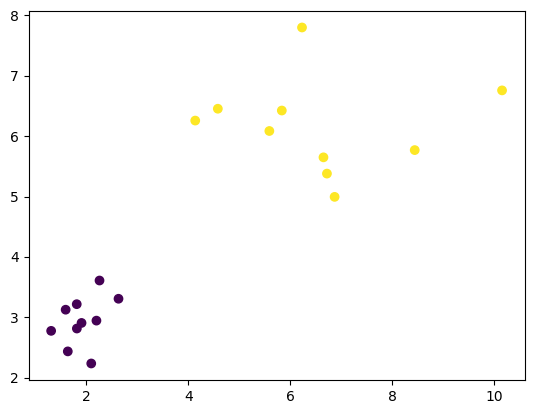

In [ ]:
plt.scatter(
    X[:, 0], X[:, 1], c=labels
)
plt.show()

##### PCA

Calculando média, covariância, autovalores e autovetores:

In [ ]:
media = np.mean(X, axis=0) # calculando a media por dimensao
X_c = X - media # calculando a media do dataset

cov = np.cov(X_c.T) # calculando a covariancia
eigvals, eigvecs = np.linalg.eigh(cov) # usando a biblioteca de alglin para calcular auto-valor/vetor

print(f'eigenvalues:')
print(f'{eigvals}')
print()
print(f'eigenvectors:')
print(f'{eigvecs}')

eigenvalues:
[0.72654939 9.47713803]

eigenvectors:
[[ 0.52125213 -0.85340273]
 [-0.85340273 -0.52125213]]


Ordenando os autovalores e autovetores:

In [ ]:
idx = eigvals.argsort()[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

print(f'eigenvalues:')
print(f'{eigvals}')
print()
print(f'eigenvectors:')
print(f'{eigvecs}')

eigenvalues:
[9.47713803 0.72654939]

eigenvectors:
[[-0.85340273  0.52125213]
 [-0.52125213 -0.85340273]]


Taxa de dispersão por *feature*:

In [ ]:
pc1 = eigvecs[:, 0]
pc2 = eigvecs[:, 1]

var_expl = eigvals / eigvals.sum() * 100
print(f'{var_expl}')

[92.87954088  7.12045912]


Plotando o gráfico de dispersão e histogramas por features:

In [ ]:
fig = make_subplots(
    rows=2, cols=2,
    specs=[[{"rowspan": 2}, {}],
           [None, {}]],
    column_widths=[0.65, 0.35],
    subplot_titles=(
        "Dados originais + PC1 e PC2 + projeções",
        "Histograma das projeções em PC1",
        "Histograma das projeções em PC2"
    )
)

# projeções escalares (coordenadas nos PCs)
proj_pc1 = X_c @ pc1
proj_pc2 = X_c @ pc2

# pontos projetados no espaço original (para visualização)
proj_pc1_points = media + np.outer(proj_pc1, pc1)
proj_pc2_points = media + np.outer(proj_pc2, pc2)

# pontos originais
fig.add_trace(
    go.Scatter(
        x=X[labels==0,0], y=X[labels==0,1],
        mode='markers', name='Classe A (concentrada)',
        marker=dict(size=10, color='#e74c3c', symbol='circle', opacity=0.9)
    ),
    row=1, col=1
)

fig.add_trace(
    go.Scatter(
        x=X[labels==1,0], y=X[labels==1,1],
        mode='markers', name='Classe B (dispersa)',
        marker=dict(size=10, color='#3498db', symbol='square', opacity=0.9)
    ),
    row=1, col=1
)

# centro
fig.add_trace(
    go.Scatter(x=[media[0]], y=[media[1]],
               mode='markers', name='Centro dos dados',
               marker=dict(size=12, color='black', symbol='x', line=dict(width=2, color='white'))),
    row=1, col=1
)

# retas PC1 e PC2
escala = 4.5
fig.add_trace(
    go.Scatter(
        x=[media[0] - pc1[0]*escala, media[0] + pc1[0]*escala],
        y=[media[1] - pc1[1]*escala, media[1] + pc1[1]*escala],
        mode='lines', name=f'PC1 ({var_expl[0]:.1f}%)',
        line=dict(color='black', width=4)
    ),
    row=1, col=1
)

fig.add_trace(
    go.Scatter(
        x=[media[0] - pc2[0]*escala, media[0] + pc2[0]*escala],
        y=[media[1] - pc2[1]*escala, media[1] + pc2[1]*escala],
        mode='lines', name=f'PC2 ({var_expl[1]:.1f}%)',
        line=dict(color='gray', width=3, dash='dot')
    ),
    row=1, col=1
)

# linhas de projeção em PC1 (tracejadas)
for i in range(len(X)):
    cor = '#e74c3c' if labels[i]==0 else '#3498db'
    fig.add_trace(
        go.Scatter(
            x=[X[i,0], proj_pc1_points[i,0]],
            y=[X[i,1], proj_pc1_points[i,1]],
            mode='lines',
            line=dict(color=cor, width=1, dash='dash'),
            showlegend=False,
            hoverinfo='skip'
        ),
        row=1, col=1
    )

# histograma PC1 (com cores por classe)
fig.add_trace(
    go.Histogram(
        x=proj_pc1[labels==0], name='Classe A – PC1',
        marker_color='#e74c3c', opacity=0.7, nbinsx=12
    ),
    row=1, col=2
)

fig.add_trace(
    go.Histogram(
        x=proj_pc1[labels==1], name='Classe B – PC1',
        marker_color='#3498db', opacity=0.7, nbinsx=12
    ),
    row=1, col=2
)

fig.add_trace(
    go.Histogram(
        x=proj_pc2[labels==0], name='Classe A – PC2',
        marker_color='#e74c3c', opacity=0.7, nbinsx=12
    ),
    row=2, col=2
)

fig.add_trace(
    go.Histogram(
        x=proj_pc2[labels==1], name='Classe B – PC2',
        marker_color='#3498db', opacity=0.7, nbinsx=12
    ),
    row=2, col=2
)

# layout geral
fig.update_layout(
    height=850,
    width=1100,
    showlegend=True,
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
    hovermode="closest",
    barmode='overlay'  # sobrepor histogramas para melhor comparação
)

fig.update_xaxes(title_text="Feature 1", row=1, col=1)
fig.update_yaxes(title_text="Feature 2", row=1, col=1)

fig.update_xaxes(title_text="Coordenada em PC1", row=1, col=2)
fig.update_xaxes(title_text="Coordenada em PC2", row=2, col=2)

fig.update_yaxes(title_text="Frequência", row=1, col=2)
fig.update_yaxes(title_text="Frequência", row=2, col=2)

# aspecto quadrado no scatter
fig.update_xaxes(scaleanchor="y", scaleratio=1, row=1, col=1)

fig.show()

## t-SNE (t-Distributed Stochastic Neighbor Embedding)

É um algoritmo clássico (lançado em 2008 por Laurens van der Maaten e Geoffrey Hinton) para redução de dimensionalidade não linear, usado principalmente para visualizar dados de alta dimensão em 2D ou 3D.

**O que ele faz?**

- Ele tenta responder:

    "Como colocar meus pontos de dados (que têm centenas ou milhares de features) em um mapa 2D de forma que pontos parecidos fiquem próximos e pontos diferentes fiquem afastados?"

- Ele foca muito na estrutura local → vizinhos próximos no espaço original ficam bem grudados no plot final;

- Cria clusters bem definidos e visualmente bonitos (por isso foi tão popular por anos em biologia, NLP, imagens, etc.);

- Usa uma distribuição t-Student (daí o "t") no espaço de baixa dimensão para evitar o "crowding problem" (pontos se amontoando no centro como acontecia em versões anteriores).

## UMAP (Uniform Manifold Approximation and Projection)

É um dos algoritmos mais populares e poderosos atualmente para redução de dimensionalidade e visualização de dados em machine learning e ciência de dados.

**O que ele faz?**

Ele pega dados com muitas dimensões (por exemplo: 100, 784, 10.000 features/dimensões) e os projeta em um espaço de poucas dimensões (quase sempre 2D ou 3D) de forma que:

- Mantém bem as relações locais (pontos que são parecidos ficam próximos);
- Preserva razoavelmente bem a estrutura global (diferentes grupos/clusters ficam separados de forma mais fiel que o t-SNE);
- É muito mais rápido que o t-SNE;
- Escala bem para datasets grandes.

## Exercícios

1. PCA é bom para qualquer distribuíção de dados? E, se a separação não for linear? E, se houver sobreposição no mesmo eixo da nuvem de dados?

2. Aplique PCA sobre o dataset [Iris](https://www.kaggle.com/datasets/uciml/iris) usando diretamente a biblioteca do sklearn - [PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html). Apresente os resultados com: pairplot (veja seaborn) e manipule o número de componentes principais a fim de obter taxa de variância diferentes de recuperação dos dados.

3. Pesquise sobre o termo: *eigenfaces*.

4. Após assista o video abaixo e implemente, também usando a bibliotecas do sklearn t-SNE e [https://umap-learn.readthedocs.io/en/latest/](https://umap-learn.readthedocs.io/en/latest/), a aplicação de t-SNE e UMAP para o dataset [Iris](https://www.kaggle.com/datasets/uciml/iris). Compare e comente os resultados.

![](https://img.youtube.com/vi/o_cAOa5fMhE/maxresdefault.jpg)

YouTube - [Latent Space Visualisation: PCA, t-SNE, UMAP](https://youtu.be/o_cAOa5fMhE)

5. Aplique as três técnicas - PCA, t-SNE e UMAP - (variando os parâmetros perplexidade sobre o dataset [https://github.com/zalandoresearch/fashion-mnist](Fashion-MNNIST) e compare os resultados.

---

## Referências

- [GeeksForGeeks - Eigenvalues and Eigenvectors](https://www.geeksforgeeks.org/engineering-mathematics/eigen-values/)

- [GeeksForGeeks - Principal Component Analysis (PCA)](https://www.geeksforgeeks.org/data-analysis/principal-component-analysis-pca/)

- [GeeksForGeeks - T-distributed Stochastic Neighbor Embedding (t-SNE) Algorithm - ML](https://www.geeksforgeeks.org/machine-learning/ml-t-distributed-stochastic-neighbor-embedding-t-sne-algorithm/)

- [DataCamp - Introduction to t-SNE](https://www.datacamp.com/tutorial/introduction-t-sne)

- [GeeksForGeeks - UMAP: Uniform Manifold Approximation and Projection](https://www.geeksforgeeks.org/machine-learning/umap-uniform-manifold-approximation-and-projection/)

- [DataCamp - Understanding UMAP](https://www.datacamp.com/tutorial/understanding-umap-guide-to-dimensionality-reduction)